# 0  

#### Il caso XOR  
OR esclusivo, di due elementi voglio uno o l'altro, non entrambi.  

#### Come si usa

Utiliziamo Binder ![](images/binder.png), un computer remoto che fa funzionare il nostro programma. Con clic su ![](images/esecuzione.png), in alto a sinistra, il progamma va in esecuzione.  

#### Che prove si possono fare  

Si opera selezionando una delle caselle indicate sotto, cosa che si ottiene _collocando all'interno della casella il cursore del mouse e facendo clic sinistro_.

Nella casella **3**, se si sostituisce *False* con *True* e si fa clic su ![](images/esecuzioneSpecifica.png), in alto a sinistra, si ottiene l'output dei parametri del modello.  

Nella casella **5** si possono sostituire i valori in input, seguendo i casi riportati qui sotto. Per eseguire la sola cella 5, in cui si sta lavorando, fare clic su ![](images/esecuzioneSpecifica.png), in alto a sinistra.

La casella **6** mostra la rete neurale, orientata da sinistra a destra; per aggiornarla indicare una delle combinazioni vero e falso e poi clic su ![](images/esecuzioneSpecifica.png), in alto a sinistra.

===================================================================================================================

#### Chiudere il programma  

Clic su **File** e poi su **Shut Down**. Meglio non uscire chiudendo brutalmente il browser.

===================================================================================================================

#### Nodi nascosti

Provare a cambiare il valore H nella casella 1 e rieseguire tutto (clic su ![](https://terna.to.it/SLM_ANN/esecuzione.png)) con il nuovo numero di nodi nascosti.

===================================================================================================================

#### Visualizzare il codice Python

Avvicinando il puntatore del mouse a sinistra di **2**, **3**, **4a** e **4b** compare &#x25B6;; cliccandolo diventa &#x25BC; e nella cella sotto compare il codice Python. L'operazione è reversibile.

===================================================================================================================

Home page dell'autore, clic su <a href="https://terna.to.it" target="_blank" rel="noopener">
  Pietro Terna
</a>

 

  
-----------------------------    
casistica, con **>** che separa l'input dall'output.


falso,falso>falso  
vero,falso>vero  
falso,vero>vero  
vero,vero>falso  

# 1
#### numero di nodi nascosti H, epoche E e dizionari di servizio

In [1]:
H = 2

E = 10000

inputPhrase =[0]*2
parolaMancante=False

dictionary = \
 {'falso': 0, 'vero': 1}
reverseDictionary= \
{0: 'falso', 1: 'vero'}

# parole in ordine di dizionario
words = [reverseDictionary[i] for i in range(len(reverseDictionary))]

# 2  
#### la rete neurale

In [2]:
# preparato da Copilot via WhatsApp
import numpy as np
import csv

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# ANN parameters
input_nodes = 2*1
hidden_nodes = H
output_nodes = 1
learning_rate = 0.5
epochs = E

# Initialize weights randomly
np.random.seed()
weights_input_hidden = np.random.rand(hidden_nodes, input_nodes + 1) - 0.5  # +1 for bias
weights_hidden_output = np.random.rand(output_nodes, hidden_nodes + 1) - 0.5  # +1 for bias

# Training phase
def train(inputs, expected_output):
    global weights_input_hidden, weights_hidden_output
    
    inputs_with_bias = np.append(inputs, 1)  # Add bias to inputs
    hidden_inputs = np.dot(weights_input_hidden, inputs_with_bias)
    hidden_outputs = sigmoid(hidden_inputs)
    
    hidden_outputs_with_bias = np.append(hidden_outputs, 1)  # Add bias to hidden outputs
    final_inputs = np.dot(weights_hidden_output, hidden_outputs_with_bias)
    final_outputs = sigmoid(final_inputs)
    
    # Error calculation
    output_error = expected_output - final_outputs
    hidden_error = np.dot(weights_hidden_output[:, :-1].T, output_error) * sigmoid_derivative(hidden_outputs)

    # Update weights
    weights_hidden_output += learning_rate * np.outer(output_error * sigmoid_derivative(final_outputs), hidden_outputs_with_bias)
    weights_input_hidden += learning_rate * np.outer(hidden_error, inputs_with_bias)

# Forward application phase with activations display
def forward_pass_with_activations(inputs):
    inputs_with_bias = np.append(inputs, 1)  # Add bias to inputs
    hidden_inputs = np.dot(weights_input_hidden, inputs_with_bias)
    hidden_outputs = sigmoid(hidden_inputs)
    
    print("Activation levels of hidden nodes (not considering the constant one):")
    print(hidden_outputs)
    
    hidden_outputs_with_bias = np.append(hidden_outputs, 1)  # Add bias to hidden outputs
    final_inputs = np.dot(weights_hidden_output, hidden_outputs_with_bias)
    final_outputs = sigmoid(final_inputs)
    
    print("\nActivation levels of output nodes:")
    print(final_outputs[0:17])
    print(final_outputs[17:])
    
    return final_outputs

# Example data
training_inputs =[]
with open("in.txt", 'r') as file1:
    for line in file1:
        # Remove leading/trailing whitespace and brackets
        line = line.strip().strip('[]')
        # Split the line into individual numbers and convert to integers
        numbers = [float(num.strip()) for num in line.split(',')]
        training_inputs.append(numbers)
#print(training_inputs)

training_outputs =[]
with open("ou.txt", 'r') as file2:
    for line in file2:
        # Remove leading/trailing whitespace and brackets
        line = line.strip().strip('[]')
        # Split the line into individual numbers and convert to integers
        numbers = [float(num.strip()) for num in line.split(',')]
        training_outputs.append(numbers)
#print(training_outputs)

# Train the network
for epoch in range(epochs):
    for i in range(len(training_inputs)):
        train(training_inputs[i], training_outputs[i])



# 3
#### output eventuale dei parametri (weights)

In [3]:
#to show the weights change to True and run
show=False


if show:
    # Display final weight matrices
    print("Weights from input to hidden layer after learning:")
    for i in range(len(weights_input_hidden)):
        print(weights_input_hidden[i])
    print("\nWeights from hidden to output layer after learning:")
    for i in range(len(weights_hidden_output)):
        print(weights_hidden_output[i])

# 4
#### funzione di servizio per gli esperimenti con gli istogrammi

In [4]:
# Esperimenti input/output con istogramma

import matplotlib.pyplot as plt
import numpy as np

def inOutExperiments(word1, word2):
    # trasforma le parole in valori numerici
    if word1 not in dictionary or word2 not in dictionary:
        print("Parola non riconosciuta.")
        print("Parole ammesse:", words)
        return None

    input_values = np.array([
        dictionary[word1],
        dictionary[word2]
    ], dtype=float)

    # applica la rete
    output_values = forward_pass_with_activations(input_values)
    output_value = float(output_values[0])

    # interpreta l'output
    output_word = "vero" if output_value >= 0.5 else "falso"

    print()
    print("Input:")
    print("input1:", word1, "=", input_values[0])
    print("input2:", word2, "=", input_values[1])

    print()
    print("Output numerico:")
    print(output_value)

    print()
    print("Output interpretato:")
    print(output_word)

    # istogramma input/output
    labels = [
        f"input1: {word1}",
        f"input2: {word2}",
        f"output: {output_word}"
    ]

    values = [
        input_values[0],
        input_values[1],
        output_value
    ]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values)

    plt.ylim(0, 1)
    plt.ylabel("Valore")
    plt.title(f"Esperimento: {word1}, {word2} → {output_word}")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    return output_word, output_value

# 5
#### esperimenti, con istogrammi

Activation levels of hidden nodes (not considering the constant one):
[5.66584539e-06 4.72348289e-02]

Activation levels of output nodes:
[0.10000001]
[]

Input:
input1: vero = 1.0
input2: vero = 1.0

Output numerico:
0.10000000618933289

Output interpretato:
falso


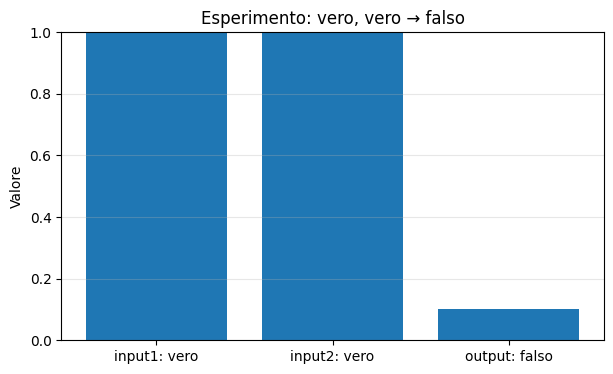

('falso', 0.10000000618933289)

In [8]:
inOutExperiments("vero","vero")

# 5
#### funzioni di servizio per la visualizzazione della rete

In [6]:
# --- Visualizzazione 3 layer per XOR: input -> hidden -> output ---
# Requisiti:
# - weights_input_hidden, weights_hidden_output già definiti
# - dictionary, reverseDictionary, words già definiti
# - sigmoid già definita

def build_inExp_XOR(word1, word2):
    """
    Costruisce il vettore input per XOR.
    Esempio:
    build_inExp_XOR("falso", "vero") -> array([0., 1.])
    """
    if word1 not in dictionary or word2 not in dictionary:
        print("Parola non riconosciuta.")
        print("Parole ammesse:", words)
        return None

    return np.array([
        dictionary[word1],
        dictionary[word2]
    ], dtype=float)


def forward_activations_XOR(inExp):
    """
    Restituisce le attivazioni:
    input, hidden, output

    I bias sono usati nel forward,
    ma non sono restituiti tra le attivazioni ordinarie.
    """
    inExp = np.asarray(inExp, dtype=float).reshape(-1)

    # input -> hidden
    inp_with_bias = np.append(inExp, 1.0)
    hidden_in = weights_input_hidden @ inp_with_bias
    hidden_out = sigmoid(hidden_in)

    # hidden -> output
    hidden_with_bias = np.append(hidden_out, 1.0)
    out_in = weights_hidden_output @ hidden_with_bias
    out_out = sigmoid(out_in)

    return inExp, hidden_out, out_out


def plot_3layer_network_XOR(word1, word2, min_edge_strength=0.0):
    """
    Disegna la rete XOR a 3 layer:

    input1, input2 -> hidden nodes -> output

    Include anche i nodi di bias.

    - dimensione nodo proporzionale all'attivazione
    - spessore arco proporzionale a |attivazione_sorgente * peso|
    - arco rosso se peso positivo
    - arco blu se peso negativo
    """

    inExp = build_inExp_XOR(word1, word2)

    if inExp is None:
        return None

    inp_act, hid_act, out_act = forward_activations_XOR(inExp)

    output_value = float(out_act[0])
    output_word = "vero" if output_value >= 0.5 else "falso"

    # aggiungi bias come nodi espliciti
    inp_act_b = np.append(inp_act, 1.0)
    hid_act_b = np.append(hid_act, 1.0)

    # numero nodi
    n_in = inp_act_b.size          # 2 input + bias
    n_h = hid_act_b.size           # H hidden + bias
    n_out = out_act.size           # 1 output

    # posizioni nodi
    y_in = np.linspace(0, 1, n_in)
    y_h = np.linspace(0, 1, n_h)
    y_out = np.array([0.5])

    x_in, x_h, x_out = 0.0, 1.0, 2.0

    # dimensione nodi
    node_base = 80
    node_scale = 900

    s_in = node_base + node_scale * inp_act_b
    s_h = node_base + node_scale * hid_act_b
    s_out = node_base + node_scale * out_act

    # etichette
    in_labels = [
        f"input1: {word1}",
        f"input2: {word2}",
        "BIAS"
    ]

    hidden_labels = [
        f"H{j}" for j in range(hid_act.size)
    ] + ["BIAS"]

    out_labels = [
        f"output: {output_word}\n{output_value:.3f}"
    ]

    # archi input -> hidden
    edges_ih = []
    strength_ih = []
    color_ih = []

    for i_in, a_in in enumerate(inp_act_b):
        wcol = weights_input_hidden[:, i_in]

        for j_h in range(hid_act.size):
            w = wcol[j_h]
            s = abs(a_in * w)

            if s <= min_edge_strength:
                continue

            edges_ih.append(
                ((x_in, y_in[i_in]), (x_h, y_h[j_h]))
            )
            strength_ih.append(s)
            color_ih.append("red" if w > 0 else "blue")

    # archi hidden -> output
    edges_ho = []
    strength_ho = []
    color_ho = []

    for j_h, a_h in enumerate(hid_act_b):
        w = weights_hidden_output[0, j_h]
        s = abs(a_h * w)

        if s <= min_edge_strength:
            continue

        edges_ho.append(
            ((x_h, y_h[j_h]), (x_out, y_out[0]))
        )
        strength_ho.append(s)
        color_ho.append("red" if w > 0 else "blue")

    # normalizzazione spessori
    all_strength = np.array(strength_ih + strength_ho, dtype=float)

    if all_strength.size == 0:
        print("Nessun arco sopra soglia.")
        return None

    s_max = all_strength.max()
    lw_min = 0.4
    lw_max = 4.5

    def lw(s):
        return lw_min + (lw_max - lw_min) * (s / s_max)

    # plot
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_axis_off()

    # disegna archi input -> hidden
    for (p0, p1), s, c in zip(edges_ih, strength_ih, color_ih):
        ax.plot(
            [p0[0], p1[0]],
            [p0[1], p1[1]],
            linewidth=lw(s),
            alpha=0.7,
            color=c
        )

    # disegna archi hidden -> output
    for (p0, p1), s, c in zip(edges_ho, strength_ho, color_ho):
        ax.plot(
            [p0[0], p1[0]],
            [p0[1], p1[1]],
            linewidth=lw(s),
            alpha=0.6,
            color=c
        )

    # disegna nodi
    ax.scatter([x_in] * n_in, y_in, s=s_in, alpha=0.9)
    ax.scatter([x_h] * n_h, y_h, s=s_h, alpha=0.9)
    ax.scatter([x_out] * n_out, y_out, s=s_out, alpha=0.9)

    # etichette input
    for i, lab in enumerate(in_labels):
        ax.text(
            x_in - 0.05,
            y_in[i],
            lab,
            va="center",
            ha="right",
            fontsize=10
        )

    # etichette hidden
    for j, lab in enumerate(hidden_labels):
        ax.text(
            x_h,
            y_h[j],
            lab,
            va="center",
            ha="center",
            fontsize=9
        )

    # etichetta output
    ax.text(
        x_out + 0.05,
        y_out[0],
        out_labels[0],
        va="center",
        ha="left",
        fontsize=10
    )

    # titoli layer
    ax.text(
        x_in,
        1.08,
        "INPUT",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold"
    )

    ax.text(
        x_h,
        1.08,
        "HIDDEN",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold"
    )

    ax.text(
        x_out,
        1.08,
        "OUTPUT",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold"
    )

    plt.title(
        f"Rete neurale: {word1} XOR {word2} → {output_word}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

    return output_word, output_value

# 6
#### disegno della rete

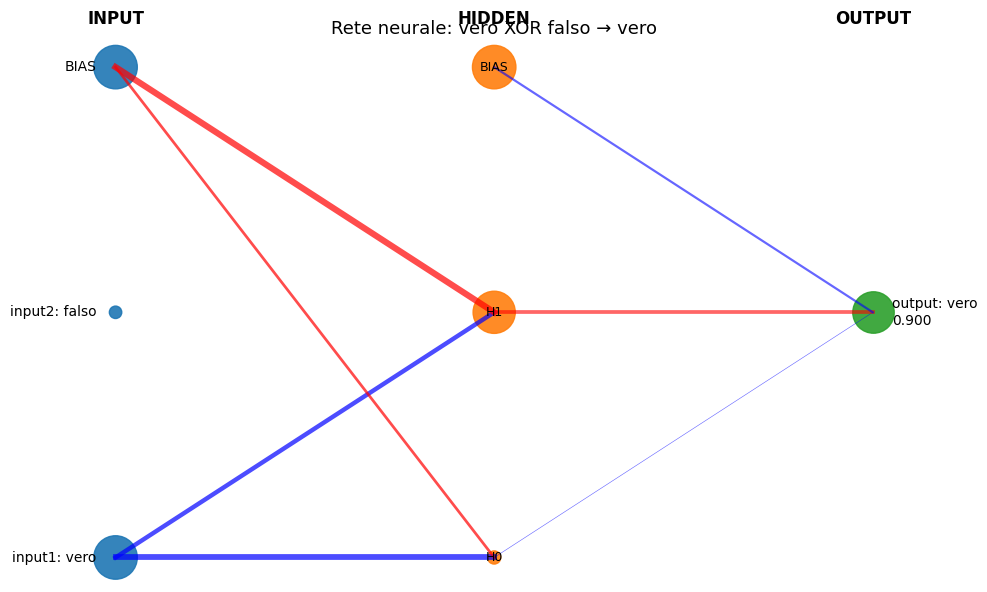

('vero', 0.8999999967957834)

In [7]:
plot_3layer_network_XOR("vero", "falso")

In $\textcolor{blue}{blu}$ i link, o collegamenti, o sinapsi, con effetto negativo; in $\textcolor{red}{rosso}$ quelli che effetto positivo.  

I nodi in input (colore $\textcolor{Periwinkle}{blu~spento}$) oppure intermedi (colore $\textcolor{darkorange}{arancione}$) o finali (colore $\textcolor{green}{verde}$) sono nulli o positivi e sono disegnati con la dimensione proporzionale al valore.